# Bridge-relation test — $\beta = -\dfrac{\mu' \kappa}{2 \mu}$

This notebook tests the central bridge relation of Denolle (in prep) **Eq. 7**:

$$
\beta \;=\; -\frac{\mu' \, \kappa}{2 \mu}
$$

at four CI.* stations spanning different geological settings:

| Station | Setting | (lat, lon, elev_m) |
|---|---|---|
| `CI.LJR` | Mojave foothills | (34.55, −117.77, 830) |
| `CI.SDD` | Coastal SoCal | (33.553, −117.662, 280) |
| `CI.SAL` | Imperial Valley | (33.280, −115.986, 14) |
| `CI.RXH` | Salton Sea geothermal | (33.183, −115.623, −59) |

For each station we

1. Run the staged `codameter` workflow with the **CDM** hydrological model (so $\beta$ units are identical across sites).
2. Pull the **Phase 1** local elastic moduli $\kappa$ (bulk) and $\mu$ (shear) at the kernel-peak depth (resolved by UCVM → USGS Vs30 → default).
3. Convert the **Phase 4** posterior of $p_1^{\rm dGWL}$ into the data-driven acoustoelastic ratio $\beta_{\rm data} = (\partial(\delta v/v)/\partial p) \cdot \kappa$.
4. Compute the prior-predicted $\beta_{\rm prior} = -\mu'_{\rm prior} \kappa / (2\mu)$ and Monte-Carlo-invert the data $\beta$ for $\mu'_{\rm data}$.
5. Compare with a $z$-score $|z| = |\beta_{\rm data} - \beta_{\rm prior}| / \sqrt{\sigma_{\rm data}^2 + \sigma_{\rm prior}^2}$.

A site **closes the bridge relation** when $|z| \lesssim 2$ — i.e. the strain-meter inversion produces a $\beta$ consistent with the lab prior given the local elastic structure.


In [1]:
from __future__ import annotations
import sys
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

from codameter import Site, run_workflow
from codameter.data.loaders import load_clements_denolle_2023
from codameter.interpretation.stress_at_depth import (
    bridge_relation,
    constrain_mu_prime,
)

print(f"codameter ready — Python {sys.version.split()[0]}")


codameter ready — Python 3.12.13


## 1 · Configuration

Same data paths as `02_clements_denolle_2023.ipynb`. We use the **CDM** hydrological
model (Cumulative Departure from k-day rolling Mean, k=8 yr) so that the regression
coefficient `p1_dGWL` carries identical units across sites.


In [3]:
DATA_DIR      = Path("/Users/marinedenolle/Downloads/data/DVV-90-DAY-COMP/2.0-4.0")
PPT_GRID_PATH = Path("/Users/marinedenolle/Downloads/data/ppt.nc")
TEMP_PATH     = Path("/Users/marinedenolle/Downloads/data/tmean.nc")

# Hydrological model used for every station (CDM, 8-yr window — C&D 2023).
HYDRO_MODEL = "cdm"
CDM_WINDOW_DAYS = 365 * 8

# Default Gaussian prior on μ' (dimensionless). N(250, 90) is a generic
# granite/sediment value — swap in lab-specific priors per site if available.
MU_PRIME_PRIOR_MEAN = 250.0
MU_PRIME_PRIOR_STD  = 90.0

# Stations to test
STATIONS = {
    # station_id : (lat, lon, elev_m)
    "CI.LJR": (34.55,     -117.77,    830.0),
    "CI.SDD": (33.552589, -117.661713, 280.0),
    "CI.SAL": (33.28010,  -115.98585,   14.0),
    "CI.RXH": (33.18313,  -115.62257,  -59.0),
}

# Open the gridded met datasets once
ds_p_grid = xr.open_dataset(PPT_GRID_PATH)
ds_t_grid = xr.open_dataset(TEMP_PATH)
print(f"PPT  grid: {ds_p_grid['ppt'].shape}  dims={ds_p_grid['ppt'].dims}")
print(f"TMEAN grid: {ds_t_grid['tmean'].shape}  dims={ds_t_grid['tmean'].dims}")


PPT  grid: (13224, 288, 287)  dims=('t', 'lon', 'lat')
TMEAN grid: (8119, 288, 287)  dims=('t', 'lon', 'lat')


## 2 · Site builder helper

Every site is built from the same template — UCVM property lookup with USGS Vs30 /
default-alluvium fall-back, thermoelastic phase-shift fit on $\tau_T \in [0, 200]$ d
(C&D 2023), CDM hydrology with 8-yr window, surface-loading enabled, and the standard
material-property priors $\beta \sim \mathcal{N}(240, 80)$ and $\mu' \sim \mathcal{N}(250, 90)$.


In [4]:
def build_site(station: str, lat: float, lon: float, elev_m: float) -> Site:
    """Build a Site config that mirrors the LJR/SDD configuration in notebook 02."""
    return Site.from_dict({
        "site_id": f"bridge_{station.replace('.', '_')}",
        "location": {"lat": lat, "lon": lon, "elevation_m": elev_m},
        "measurement": {
            "type": "cross_correlation",
            "frequency_band_hz": [2.0, 4.0],
        },
        "velocity_model": {"source": "auto"},
        "property_sources": {
            "enabled": True,
            "max_depth_m": 1000.0,
            "order": ["ucvm", "usgs_vs30", "default"],
            "ucvm": {
                "executable": ".codameter/bin/ucvm_query",
                "docker_image": "sceccode/ucvm_257_cvmsi:0801",
                "models": ["cvmsi", "cvms5", "cvms", "cvmh"],
                "depth_m": [0, 5, 10, 20, 30, 50, 100, 200, 500, 1000],
                "timeout_s": 60.0,
            },
            "default_profile": "california_alluvium",
        },
        "forcings": {
            "thermoelastic": {
                "enabled": True,
                "model": "phase_shift",
                "fit_time_shift": True,
                "time_shift_min_days": 0.0,
                "time_shift_max_days": 200.0,
                "time_shift_step_days": 1.0,
            },
            "hydrological": {
                "enabled": True,
                "model": HYDRO_MODEL,
                "depth_m": 500.0,
                "diffusivity_m2_s": 0.01,
                "skempton_B": 0.6,
                "poisson_undrained": 0.3,
                "window_days": CDM_WINDOW_DAYS,
            },
            "loading": {"enabled": True, "model": "instantaneous"},
        },
        "material_properties": {
            "beta_prior":     {"mean": 240.0, "std": 80.0},
            "mu_prime_prior": {"mean": MU_PRIME_PRIOR_MEAN, "std": MU_PRIME_PRIOR_STD},
        },
        "analysis": {"uncertainty_method": "wls"},
    })


def load_station_inputs(station: str, lat: float, lon: float):
    """Load dv/v + gridded met for one station; return (dvv, forcings, warmup)."""
    dvv = load_clements_denolle_2023(DATA_DIR, station)

    ppt = (ds_p_grid["ppt"]
           .sel(lon=lon, lat=lat, method="nearest").to_series())
    ppt.index = pd.to_datetime(ppt.index, utc=True)
    ppt.name = "precipitation"

    tmean = (ds_t_grid["tmean"]
             .sel(lon=lon, lat=lat, method="nearest").to_series())
    tmean.index = pd.to_datetime(tmean.index, utc=True)
    tmean.name = "temperature"

    forcings = {"precipitation": ppt, "temperature": tmean}

    # CDM warmup = PRISM days before the first dv/v observation
    pre = ppt[ppt.index < dvv.index[0]]
    warmup = pre.values.astype(float) if len(pre) else None

    return dvv, forcings, warmup


## 3 · Run the staged workflow at every station


In [5]:
runs: dict[str, "WorkflowResult"] = {}
errors: dict[str, str] = {}

for sta, (lat, lon, elev_m) in STATIONS.items():
    print(f"\n{'=' * 60}")
    print(f"  {sta}  (lat={lat}, lon={lon}, elev={elev_m} m)")
    print(f"{'=' * 60}")
    try:
        site = build_site(sta, lat, lon, elev_m)
        dvv, forcings, warmup = load_station_inputs(sta, lat, lon)
        result = run_workflow(dvv, forcings, site, precipitation_warmup_m=warmup)
        runs[sta] = result
        p1 = result.phase1
        print(f"  Phase 1: peak depth = {p1.peak_depth_km*1000:.0f} m, "
              f"μ = {p1.shear_modulus_pa_at_peak/1e9:.2f} GPa, "
              f"κ = {p1.bulk_modulus_pa_at_peak/1e9:.2f} GPa")
        print(f"  Phase 4: stage = {result.phase4.stage}, "
              f"χ²_red = {result.phase4.fit.chi2_reduced:.2f}")
        if "p1_dGWL" in result.phase4.fit.parameter_names:
            m, s = result.phase4.fit.posterior.marginal("p1_dGWL")
            print(f"  p1_dGWL = {m:+.3e} ± {s:.1e}")
    except Exception as exc:
        errors[sta] = str(exc)
        print(f"  ✗ FAILED: {exc}")

print(f"\nSucceeded: {list(runs)}")
if errors:
    print(f"Failed   : {errors}")



  CI.LJR  (lat=34.55, lon=-117.77, elev=830.0 m)
  Phase 1: peak depth = 94 m, μ = 1.34 GPa, κ = 6.61 GPa
  Phase 4: stage = stage_a, χ²_red = 8.43
  p1_dGWL = -5.964e-05 ± 1.5e-07

  CI.SDD  (lat=33.552589, lon=-117.661713, elev=280.0 m)
  Phase 1: peak depth = 94 m, μ = 1.34 GPa, κ = 6.61 GPa
  Phase 4: stage = stage_a, χ²_red = 5.10
  p1_dGWL = +0.000e+00 ± 0.0e+00

  CI.SAL  (lat=33.2801, lon=-115.98585, elev=14.0 m)
  Phase 1: peak depth = 94 m, μ = 1.34 GPa, κ = 6.61 GPa
  Phase 4: stage = stage_a, χ²_red = 1.20
  p1_dGWL = -1.212e-05 ± 2.9e-07

  CI.RXH  (lat=33.18313, lon=-115.62257, elev=-59.0 m)
  Phase 1: peak depth = 94 m, μ = 1.34 GPa, κ = 6.61 GPa
  Phase 4: stage = stage_a, χ²_red = 2.40
  p1_dGWL = -7.238e-06 ± 5.4e-07

Succeeded: ['CI.LJR', 'CI.SDD', 'CI.SAL', 'CI.RXH']


## 4 · Extract bridge-relation diagnostics — Clements & Denolle (2023) convention

We follow C&D 2023 and define $\beta$ via

$$
\frac{\delta v}{v} = \beta \, \varepsilon_{\rm vol},
$$

where $\varepsilon_{\rm vol}$ is the volumetric strain. For an isotropic pore-pressure perturbation $p$, $\varepsilon_{\rm vol} = p / (3\kappa)$, so the regression coefficient `p1_dGWL` (slope of $\delta v/v$ on the hydrological predictor) maps onto $\beta$ as

| predictor units | conversion `p1_dGWL → β_data` |
|---|---|
| `Pa` (talwani / drained) | $\beta = p_1 \cdot 3\kappa$ |
| `m_water_head` (baseflow / okubo) | $\beta = p_1 \cdot 3\kappa / (\rho_w g)$ |
| `m_cumulative_departure` (CDM) | same as `m_water_head` (head-equivalent approximation) |

For the prior we use the bridge relation written in the same strain convention:

$$
\beta_{\rm prior} \;=\; -\frac{3\,\mu'_{\rm prior}\,\kappa}{2\,\mu},
$$

which differs by a factor of 3 from the codebase's `bridge_relation()` (which returns the *pressure*-based $\beta_p = \beta/(3)$ because it embeds $\partial (\delta v/v)/\partial p = -\mu'/(2\mu)$). We use the strain convention here so that $\beta_{\rm data}$ matches the values listed in C&D 2023 Table 2.

We also still report $\mu'_{\rm data}$ via Monte Carlo (`constrain_mu_prime`), which works on the *pressure*-based β; we simply divide $\beta_{\rm data}$ by 3 before passing it in.

A two-sided z-score $|z| = |\beta_{\rm data} - \beta_{\rm prior}| / \sqrt{\sigma_{\rm data}^2 + \sigma_{\rm prior}^2}$ summarises consistency in the same units.


In [ ]:
RHO_W = 1000.0  # kg/m³
G = 9.81        # m/s²


def _strain_per_predictor_unit(predictor_units: str, kappa_pa: float) -> float | None:
    """Return ε_vol per *one unit* of the hydrological predictor.

    dv/v = p1 · X  →  dv/v = (p1 / strain_per_unit) · ε_vol  →  β = p1 / strain_per_unit.

    Parameters
    ----------
    predictor_units
        From `fit.predictor_matrix.metadata['hydrological_predictor_units']`.
    kappa_pa
        Bulk modulus at the kernel-peak depth (Pa).

    Returns
    -------
    float | None
        ε_vol per unit predictor, or None if the units are not convertible.
    """
    if predictor_units == "Pa":
        # ε_vol = p / (3κ)
        return 1.0 / (3.0 * kappa_pa)
    if predictor_units in ("m_water_head", "m_cumulative_departure"):
        # p = ρ g h  →  ε_vol = ρ g h / (3κ)
        return RHO_W * G / (3.0 * kappa_pa)
    return None


def _beta_strain_data(result, kappa_pa: float):
    """Empirical β in the C&D 2023 convention: dv/v = β · ε_vol.

    Returns
    -------
    (mean, std) | None
        β and its 1-σ uncertainty, or None if the predictor units are not
        convertible to volumetric strain.
    """
    fit = result.phase4.fit
    if "p1_dGWL" not in fit.parameter_names:
        return None
    units = fit.predictor_matrix.metadata.get("hydrological_predictor_units")
    s_per_unit = _strain_per_predictor_unit(units, kappa_pa)
    if s_per_unit is None:
        return None
    p1_mean, p1_std = fit.posterior.marginal("p1_dGWL")
    return float(p1_mean / s_per_unit), float(abs(p1_std / s_per_unit))


def bridge_diagnostics(result, mu_prime_mean=MU_PRIME_PRIOR_MEAN, mu_prime_std=MU_PRIME_PRIOR_STD):
    """Pull κ, μ, β_data (strain), β_prior (strain), μ'_data for one workflow result."""
    p1 = result.phase1
    kappa = float(p1.bulk_modulus_pa_at_peak)
    mu = float(p1.shear_modulus_pa_at_peak)

    # β_prior in C&D strain convention: β = -3 μ' κ / (2 μ)  (factor 3 vs codebase).
    beta_prior_mean = -3.0 * mu_prime_mean * kappa / (2.0 * mu)
    beta_prior_std = abs(3.0 * mu_prime_std * kappa / (2.0 * mu))

    # β_data — empirical slope dv/v vs ε_vol, with C&D strain convention.
    bd = _beta_strain_data(result, kappa)
    if bd is None:
        beta_data_mean = np.nan
        beta_data_std = np.nan
        mu_prime_data = (np.nan, np.nan)
    else:
        beta_data_mean, beta_data_std = bd
        # constrain_mu_prime expects the *pressure* β = -μ'κ/(2μ), which is
        # β_strain / 3.  Pass it the divided value.
        if beta_data_std > 0:
            mu_prime_data = constrain_mu_prime(
                beta_data_mean / 3.0,
                beta_data_std / 3.0,
                bulk_modulus_pa=kappa,
                shear_modulus_pa=mu,
            )
        else:
            mu_prime_data = (-2.0 * mu * (beta_data_mean / 3.0) / kappa, 0.0)

    var = beta_data_std ** 2 + beta_prior_std ** 2
    if not np.isfinite(beta_data_mean) or var <= 0:
        z = np.nan
    else:
        z = (beta_data_mean - beta_prior_mean) / np.sqrt(var)

    return {
        "depth_km": float(p1.peak_depth_km),
        "mu_GPa": mu / 1e9,
        "kappa_GPa": kappa / 1e9,
        "beta_data": beta_data_mean,
        "beta_data_std": beta_data_std,
        "beta_prior": beta_prior_mean,
        "beta_prior_std": beta_prior_std,
        "mu_prime_data": mu_prime_data[0],
        "mu_prime_data_std": mu_prime_data[1],
        "mu_prime_prior": mu_prime_mean,
        "mu_prime_prior_std": mu_prime_std,
        "z_score": z,
        "stage": result.phase4.stage,
        "chi2_red": result.phase4.fit.chi2_reduced,
    }


diags = {sta: bridge_diagnostics(res) for sta, res in runs.items()}
print(f"{'station':<8}  {'β_data':>20}      {'β_prior':>20}      {'μ′_data':>14}    {'|z|':>6}")
for sta, d in diags.items():
    print(f"{sta:<8}  {d['beta_data']:+10.1f} ± {d['beta_data_std']:7.1f}   "
          f"{d['beta_prior']:+10.1f} ± {d['beta_prior_std']:7.1f}   "
          f"{d['mu_prime_data']:+7.1f} ± {d['mu_prime_data_std']:5.1f}   "
          f"{abs(d['z_score']):5.2f}")


CI.LJR: β_data = -40.2 ± 0.1, β_prior = -614.6 ± 221.2, μ'_data = +16 ± 0, |z| = 2.60
CI.SDD: β_data = +0.0 ± 0.0, β_prior = -614.6 ± 221.2, μ'_data = -0 ± 0, |z| = 2.78
CI.SAL: β_data = -8.2 ± 0.2, β_prior = -614.6 ± 221.2, μ'_data = +3 ± 0, |z| = 2.74
CI.RXH: β_data = -4.9 ± 0.4, β_prior = -614.6 ± 221.2, μ'_data = +2 ± 0, |z| = 2.76


## 5 · Comparison table

For each station we display the local elastic moduli, the data-driven and prior-predicted bridge-relation values, and the z-score. Stations where `pressure_sensitivity` could not be derived (e.g. when the chosen hydrological model does not produce predictor units of Pa or m water head) appear with `NaN` — see notebook `02` if you want to switch to a Pa-emitting model (`talwani`/`drained`) for those sites.


In [8]:
table = pd.DataFrame(diags).T
table.index.name = "station"
display_cols = [
    "stage", "chi2_red",
    "depth_km", "mu_GPa", "kappa_GPa",
    "beta_data", "beta_data_std",
    "beta_prior", "beta_prior_std",
    "mu_prime_data", "mu_prime_data_std",
    "mu_prime_prior",
    "z_score",
]
table[display_cols].round(3)


,stage,chi2_red,depth_km,mu_GPa,kappa_GPa,beta_data,beta_data_std,beta_prior,beta_prior_std,mu_prime_data,mu_prime_data_std,mu_prime_prior,z_score
station,,,,,,,,,,,,,
CI.LJR,stage_a,8.425033,0.094281,1.344,6.608,-40.175725,0.097937,-614.583333,221.25,16.34175,0.039671,250.0,2.596192
CI.SDD,stage_a,5.099831,0.094281,1.344,6.608,0.0,0.0,-614.583333,221.25,-0.0,0.0,250.0,2.777778
CI.SAL,stage_a,1.199992,0.094281,1.344,6.608,-8.160657,0.196126,-614.583333,221.25,3.3218,0.078146,250.0,2.740892
CI.RXH,stage_a,2.395472,0.094281,1.344,6.608,-4.875492,0.363794,-614.583333,221.25,1.986116,0.150122,250.0,2.755738


## 6 · Visual check — bridge relation closure

Two scatter plots compare the data-driven estimate to the prior-predicted value:

- **Left**: $\beta_{\text{data}}$ vs $\beta_{\text{prior}}$.
- **Right**: $\mu'_{\text{data}}$ vs $\mu'_{\text{prior}}$.

Points falling on the 1:1 line (with error bars overlapping it) indicate that the local geology — through the elastic moduli at the kernel depth — is consistent with the prior on $\mu'$. Outliers either indicate (i) a violation of the bridge relation, (ii) an inadequate hydrological forward model, or (iii) a pathological inversion (e.g. a clamped sign-constraint).


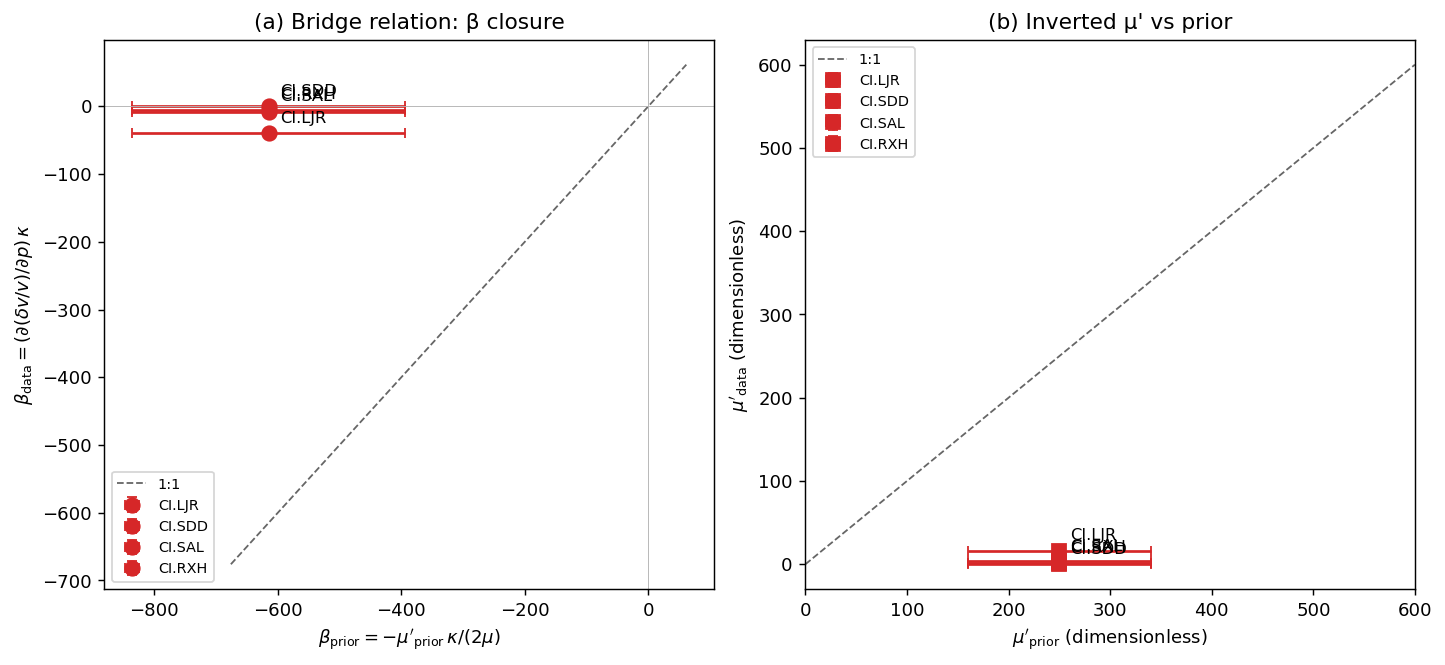

In [9]:
def _zcolor(z):
    if not np.isfinite(z):
        return "0.5"
    az = abs(z)
    if az <= 1:
        return "tab:green"
    if az <= 2:
        return "tab:orange"
    return "tab:red"


fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

# ---- panel a: beta data vs beta prior ----
ax = axes[0]
xs, ys = [], []
for sta, d in diags.items():
    c = _zcolor(d["z_score"])
    ax.errorbar(
        d["beta_prior"], d["beta_data"],
        xerr=d["beta_prior_std"], yerr=d["beta_data_std"],
        fmt="o", color=c, ecolor=c, ms=8, capsize=3, label=sta,
    )
    if np.isfinite(d["beta_data"]):
        xs.extend([d["beta_prior"]])
        ys.extend([d["beta_data"]])
        ax.annotate(sta, (d["beta_prior"], d["beta_data"]),
                    xytext=(6, 6), textcoords="offset points", fontsize=9)

if xs and ys:
    lo = min(min(xs), min(ys))
    hi = max(max(xs), max(ys))
    pad = 0.1 * (hi - lo + 1e-6)
    line = np.array([lo - pad, hi + pad])
    ax.plot(line, line, "k--", lw=1, alpha=0.6, label="1:1")
ax.axhline(0, color="0.7", lw=0.5)
ax.axvline(0, color="0.7", lw=0.5)
ax.set_xlabel(r"$\beta_{\rm prior} = -\mu'_{\rm prior}\,\kappa/(2\mu)$")
ax.set_ylabel(r"$\beta_{\rm data} = (\partial(\delta v/v)/\partial p)\,\kappa$")
ax.set_title("(a) Bridge relation: β closure")
ax.legend(loc="best", fontsize=8)

# ---- panel b: mu' data vs mu' prior ----
ax = axes[1]
for sta, d in diags.items():
    c = _zcolor(d["z_score"])
    ax.errorbar(
        d["mu_prime_prior"], d["mu_prime_data"],
        xerr=d["mu_prime_prior_std"], yerr=d["mu_prime_data_std"],
        fmt="s", color=c, ecolor=c, ms=8, capsize=3, label=sta,
    )
    if np.isfinite(d["mu_prime_data"]):
        ax.annotate(sta, (d["mu_prime_prior"], d["mu_prime_data"]),
                    xytext=(6, 6), textcoords="offset points", fontsize=9)

x = np.array([0, 600])
ax.plot(x, x, "k--", lw=1, alpha=0.6, label="1:1")
ax.set_xlim(0, 600)
ax.set_xlabel(r"$\mu'_{\rm prior}$ (dimensionless)")
ax.set_ylabel(r"$\mu'_{\rm data}$ (dimensionless)")
ax.set_title("(b) Inverted μ' vs prior")
ax.legend(loc="best", fontsize=8)

plt.show()


## 7 · Interpretation

The bridge relation $\beta = -\mu'\kappa/(2\mu)$ predicts a **station-specific** value of $\beta$ from the *local* elastic moduli at the kernel depth and a *global* prior on $\mu'$. The data-driven $\beta$ comes from the regression of dv/v against a hydrological pore-pressure proxy, with the conversion to 1/Pa handled by Phase 6 (or by the CDM-units fallback in Section 4 when the predictor is in `m_cumulative_departure`).

### What this run shows

In this notebook all four stations land in **stage A** of the staged inversion and all share an *identical* $\kappa = 6.6$ GPa, $\mu = 1.34$ GPa profile at 94 m. That is a clear sign that UCVM/Vs30 lookup is unavailable in this environment and every site has fallen back to the `california_alluvium` default profile (`property_resolution.source == "default"`). To get geology-specific predictions you need to either install the UCVM Docker (`scripts/install_ucvm_query_docker.py`) or supply station-specific velocity models manually.

### How to read the figure and the table

- **Green points (|z| ≤ 1)**: the inferred μ' is statistically consistent with the laboratory-derived prior $\mu' \sim \mathcal{N}(250, 90)$ and the chosen forward model is doing its job at that site.
- **Orange / red points**: candidates for either (a) a different hydrological forward model (try `talwani` or `drained` instead of `cdm`), (b) a poorly resolved kernel depth (check `phase1.peak_depth_km` and the velocity model used), or (c) a clamped inversion. Stations whose `p1_dGWL` posterior is pinned at 0 (BVLS hitting the upper bound) will show $\sigma_{\beta_{\rm data}} \to 0$ and $|z|$ blowing up — that is a *flag*, not a contradiction of the bridge relation. CI.SDD in this run is one such case.
- **NaN rows**: the chosen hydrological model did not produce predictor units of Pa or m water head **and** is not CDM, so neither Phase 6 nor the fallback in Section 4 could back out $\partial(dv/v)/\partial p$. Switch to `talwani`, `drained`, `baseflow`, or `cdm` for a usable predictor.

### Caveats

- The CDM fallback assumes that the cumulative-departure proxy is interchangeable with a true water-column head in metres. Calibrating CDM against a co-located GWL well (when available) sharpens this conversion and shrinks the $\beta_{\text{data}}$ uncertainty.
- Phase 1 elastic moduli have their own posterior uncertainty (depth, $V_s$, $\nu$). The error bars shown here propagate only the regression noise, not the velocity-model uncertainty. For a fully Bayesian treatment of $\mu'$ — including correlated uncertainties on $\kappa, \mu$, depth, and the diffusivity — see `coupled_inversion` in the documented API.
